In [1]:
import numpy as np
from matplotlib import pyplot as plt

import h5py

plt.style.use('../../paper.mplstyle')

In [2]:
def collect_data_results(results_filename):

    # Load in data results
    results_dict = {}
    with h5py.File(results_filename, 'r') as f:
        snr = f['snr'][:]
        valid = snr > 0
        results_dict["snr"] = snr[valid]
        results_dict["snr_A"] = f['snr_A'][valid]
        results_dict["snr_E"] = f['snr_E'][valid]
        results_dict["time_A"] = f['time_A'][valid]
        results_dict["time_E"] = f['time_E'][valid]
        results_dict["template_id"] = f['template_id'][valid]
        results_dict["time"] = (results_dict["time_A"] + results_dict["time_E"]) / 2

    return results_dict

In [3]:
times_before = [0.5, 1, 4, 7, 14]

all_results_raw = {
    time_before: collect_data_results(f"results/data_runs_raw_{time_before}_results.hdf")
    for time_before in
    times_before
}
all_results_remove = {
    time_before: collect_data_results(f"results/data_runs_remove_{time_before}_results.hdf")
    for time_before in
    times_before
}

time_colors = {
    tb: c
    for tb, c in
    zip(
        times_before,
        plt.rcParams['axes.prop_cycle'].by_key()['color']
    )
}

print(time_colors)

{0.5: '#0173b2', 1: '#de8f05', 4: '#029e73', 7: '#d55e00', 14: '#cc78bc'}


In [4]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky[0]['CoalescenceTime']

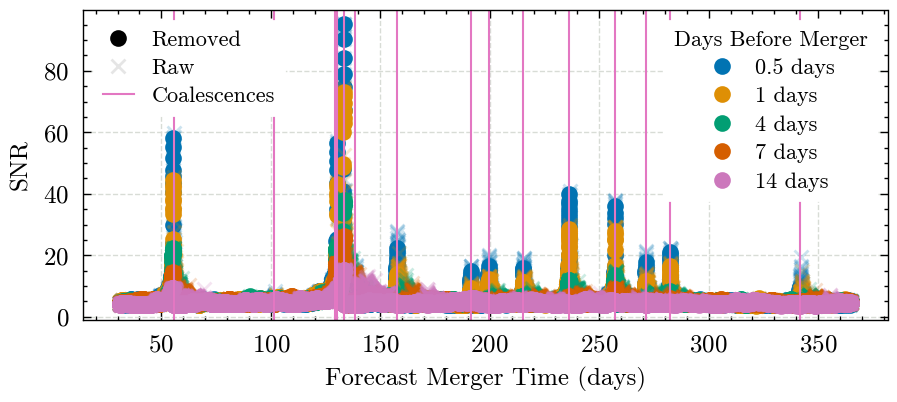

In [5]:

width = plt.rcParams["figure.figsize"][0] * 1.5
height = plt.rcParams["figure.figsize"][1]
fig, ax = plt.subplots(1, figsize=(width, height),)

for time_before in times_before:
    time_raw = all_results_raw[time_before]['time']
    snr_raw = all_results_raw[time_before]['snr']

    time_remove = all_results_remove[time_before]['time']
    snr_remove = all_results_remove[time_before]['snr']

    ax.plot(
        time_raw / 86400,
        snr_raw,
        marker='x',
        linewidth=0,
        alpha=0.2,
        color=time_colors[time_before],
    )
    ax.plot(
        time_remove / 86400,
        snr_remove,
        marker='o',
        linewidth=0,
        color=time_colors[time_before],
        label=f"{time_before} days"
    )
for i, truth_time_s in enumerate(truth_times_s):
    ax.axvline(truth_time_s / 86400, c='tab:pink')

ax.set_xlabel("Forecast Merger Time (days)")
ax.set_ylabel("SNR")
leg1 = ax.legend(loc="upper right", title='Days Before Merger')
lines = [
    ax.plot([],[], marker='o', linewidth=0, color='k')[0],
    ax.plot([],[], marker='x', alpha=0.1, linewidth=0, color='k')[0],
    ax.axvline(np.nan, c='tab:pink')
]
labels = [
    'Removed',
    'Raw',
    'Coalescences'
]
ax.legend(
    lines, labels, loc='upper left'
)
ax.add_artist(leg1)
ax.grid()

In [6]:
def plot_around_time(truth_time_s, raw_results, remove_results=None, optimal_snr_results=None, signal_number=None, time_around=2, truth_times_all=None):
    width = plt.rcParams["figure.figsize"][0] * 1.25
    height = plt.rcParams["figure.figsize"][1]
    fig, ax = plt.subplots(1, figsize=(width, height),)

    lines2 = []
    labels2 = []
    raw_alpha = 1 if remove_results is None else 0.1

    for k, v in raw_results.items():
        time = v['time']
        snr = v['snr']
        valid = np.abs(time - truth_time_s) < (time_around * 86400)
        around_time = time[valid]
        around_snr = snr[valid]

        ax.plot(
            (around_time - truth_time_s) / 86400,
            around_snr,
            marker='x',
            linewidth=0,
            alpha=raw_alpha,
            color=time_colors[k],
        )
        ax.plot(
            [],[], 
            color=time_colors[k],
            linewidth=2,
            label=f"{k} days"
        )
    if remove_results is not None:
        for k, v in remove_results.items():
            time = v['time']
            snr = v['snr']
            valid = np.abs(time - truth_time_s) < (time_around * 86400)
            around_time = time[valid]
            around_snr = snr[valid]

            ax.plot(
                (around_time - truth_time_s) / 86400,
                around_snr,
                marker='o',
                linewidth=0,
                color=time_colors[k],
            )

    
    lines2.append(
        ax.plot(
            [],
            [],
            marker='x',
            linewidth=0,
            color='k',
        )[0]
    )
    raw_label = 'Search Results' if remove_results is None else 'Raw'
    leg2_title = None if remove_results is None else 'Search Results'
    labels2.append(raw_label)
    if remove_results is not None:
        lines2.append(
            ax.plot(
                [],
                [],
                marker='o',
                linewidth=0,
                color='k',
            )[0]
        )
        labels2.append("Removed")
        
    if optimal_snr_results is not None:
        for k, v in optimal_snr_results.items():
            time = v['time']
            snr = v['SNR']
            valid = abs(time - truth_time_s) < (86400 * time_around)

            ax.plot(
                (time[valid] - truth_time_s) / 86400 ,
                snr[valid],
                marker='*',
                linewidth=0,
                color=time_colors[k],
                zorder=100
            )
        lines2.append(
            ax.plot(
                [], [],
                marker='*',
                linewidth=0,
                color='k',
                zorder=100
            )[0]
        )
        labels2.append("Optimal SNR")
        

    leg1 = plt.legend(loc='upper left', title='Time before merger')

    lines2.append(
        ax.axvline(0, c='tab:pink')
    )
    labels2.append(f'Coalescence')
    if truth_times_all is not None:
        any_nearby = False
        for i, truth_time_other in enumerate(truth_times_all):
            if truth_time_other == truth_time_s:
                continue
            if abs(truth_time_other - truth_time_s) < (time_around * 86400):
                any_nearby=True
                ax.axvline(
                    (truth_time_other - truth_time_s) / 86400,
                    color='r',
                    linestyle='--'
                )
        if any_nearby:
            lines2.append(
                ax.plot([],[], color='r', linestyle='--')[0]
            )
            labels2.append("Additional merger(s)")
    ax.set_xlim(-time_around, time_around)
    ax.set_xlabel("Forecast Merger Time - truth (days)")
    ax.set_ylabel("SNR")
    ax.grid()
    if signal_number is not None:
        ax.set_title(f"Signal {signal_number}, {truth_time_s:.1f}")
    ax.legend(lines2, labels2, loc='upper right', title=leg2_title)
    ax.add_artist(leg1)
    return fig

/local/gareth.cabourndavies/ipykernel_67652/554283998.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, figsize=(width, height),)


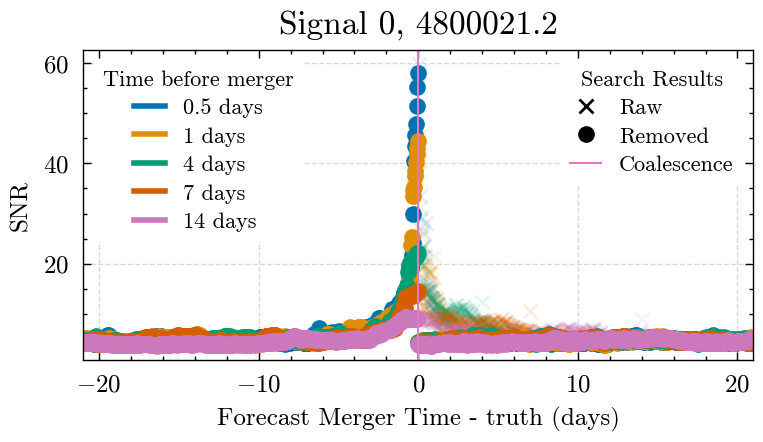

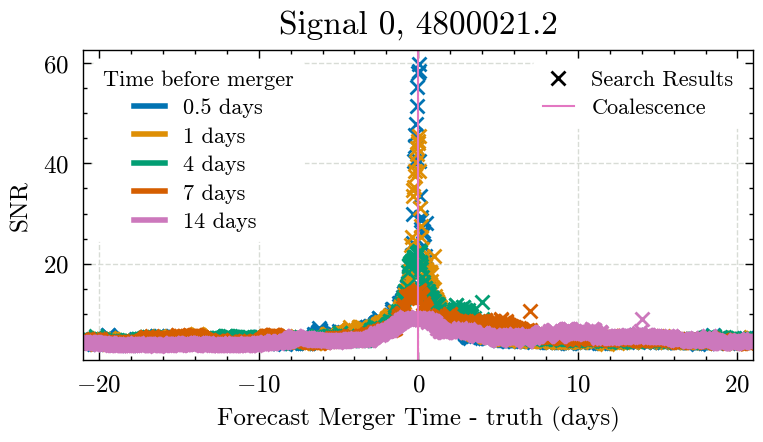

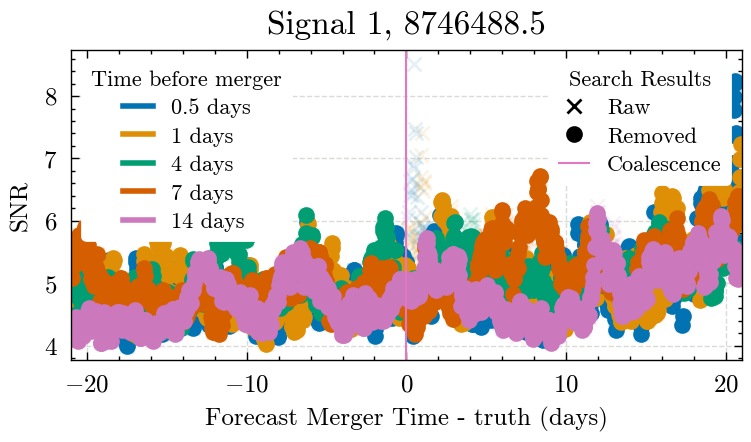

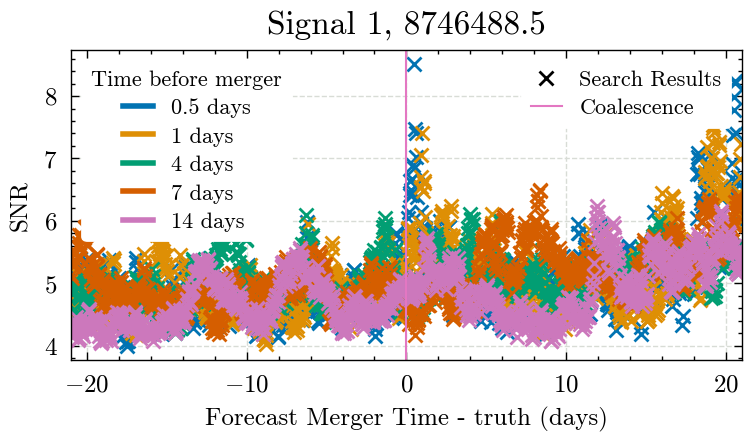

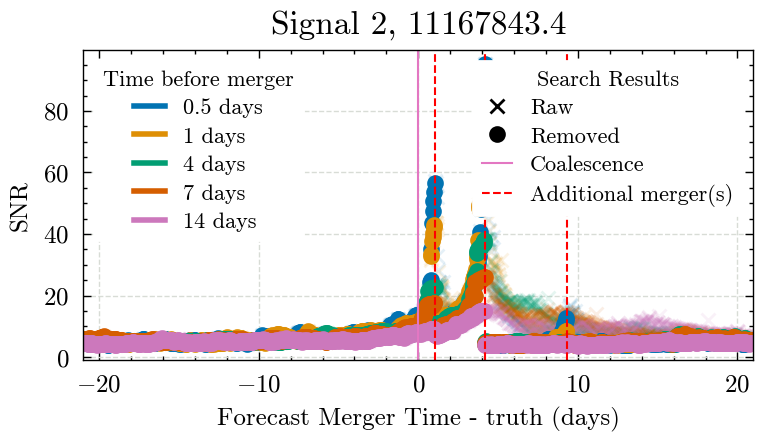

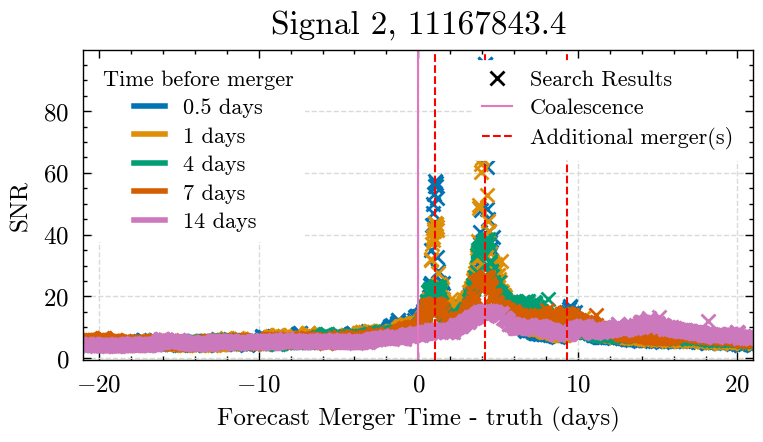

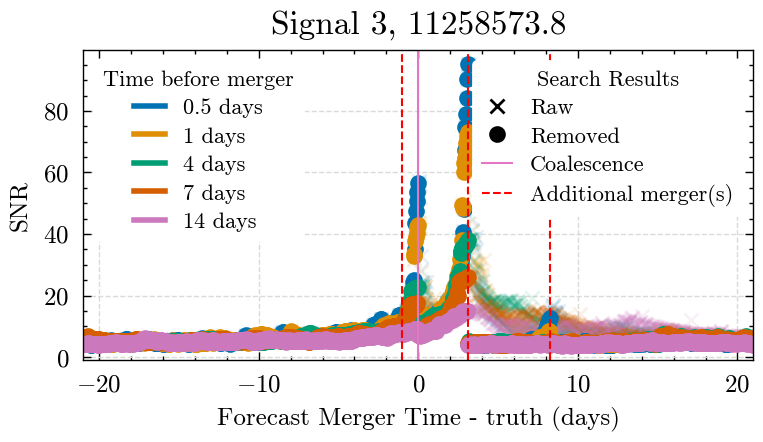

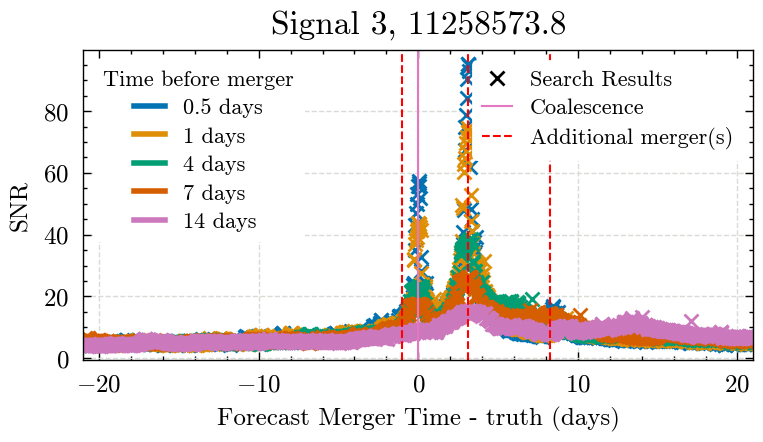

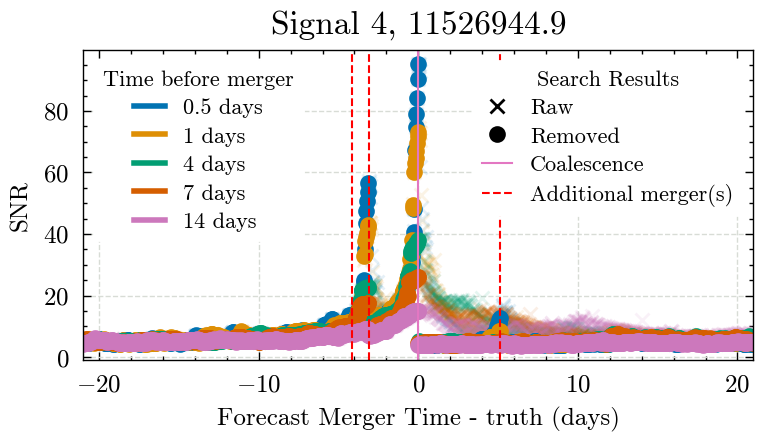

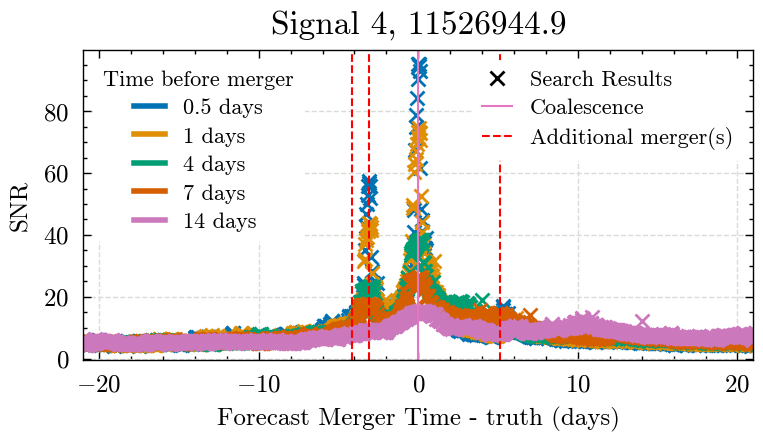

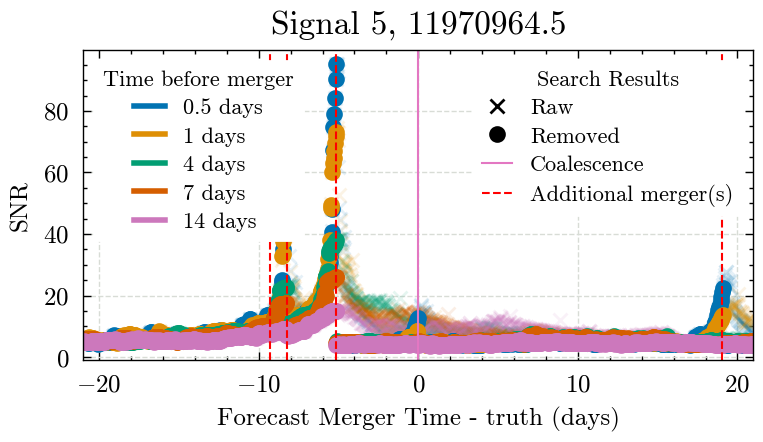

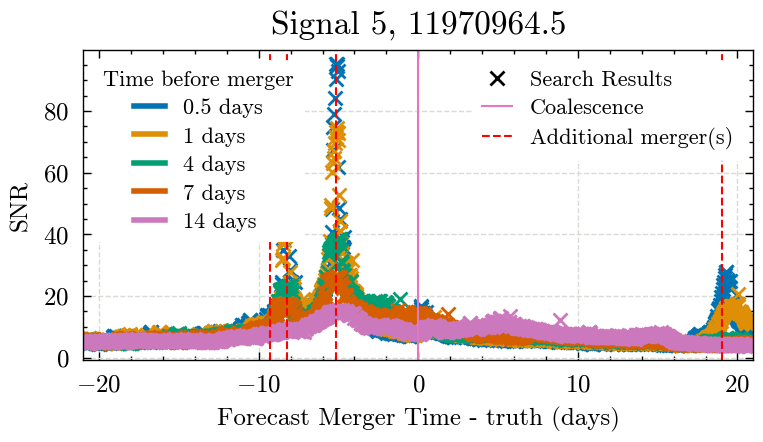

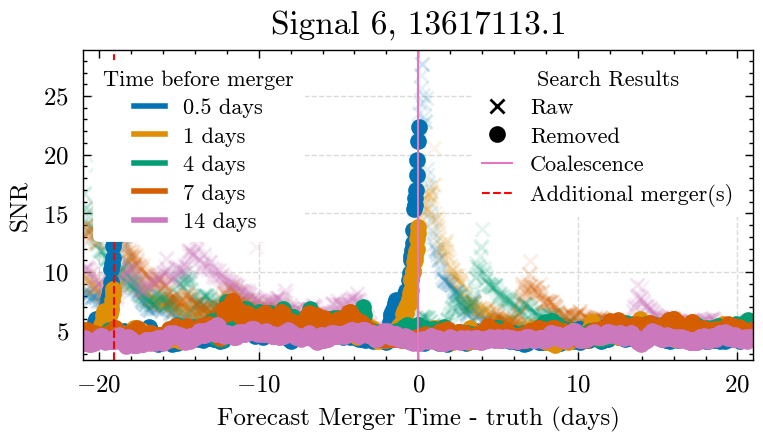

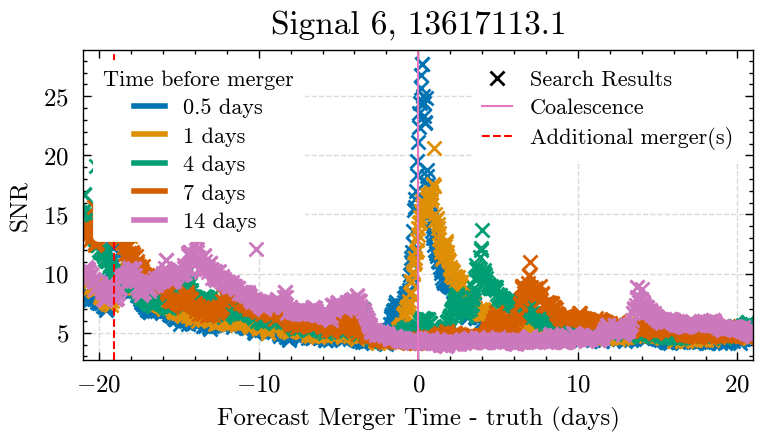

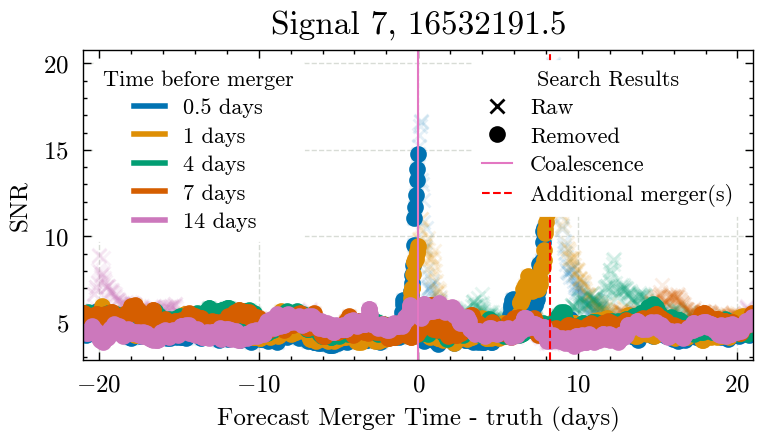

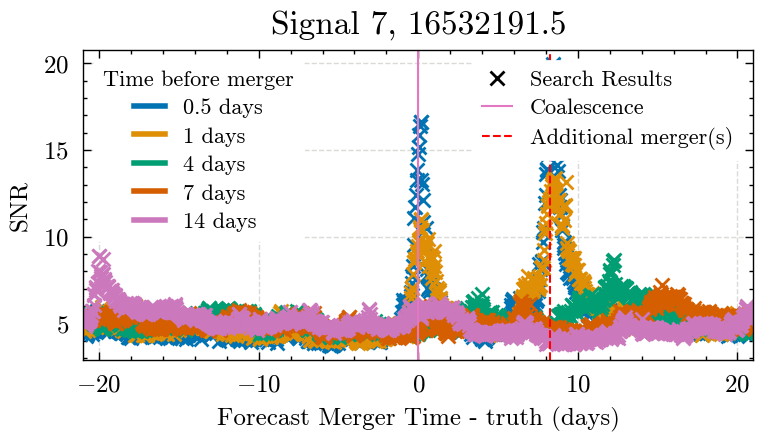

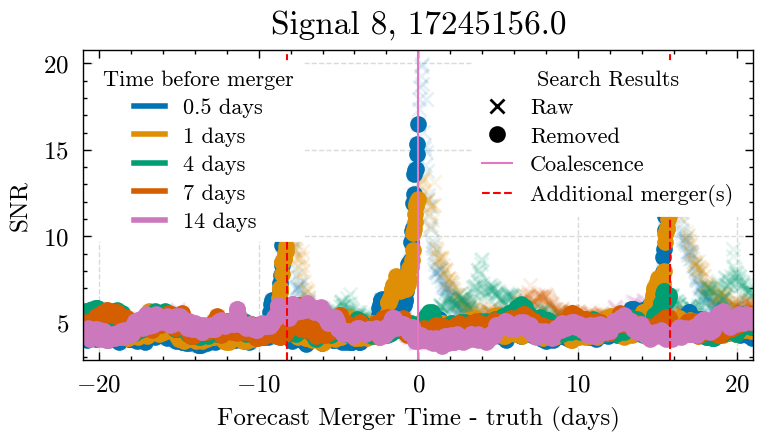

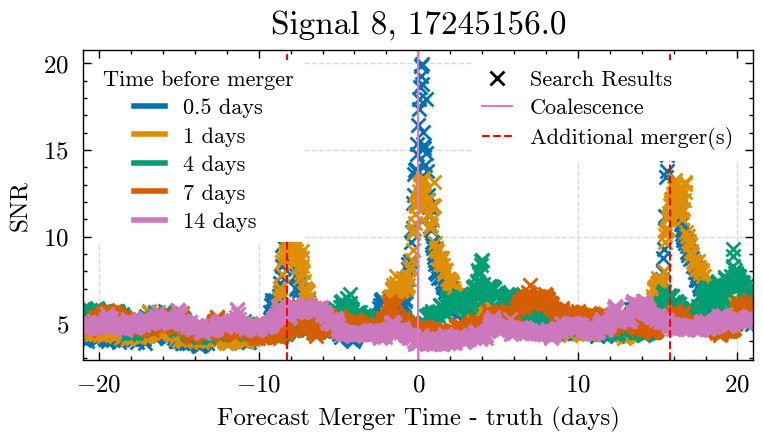

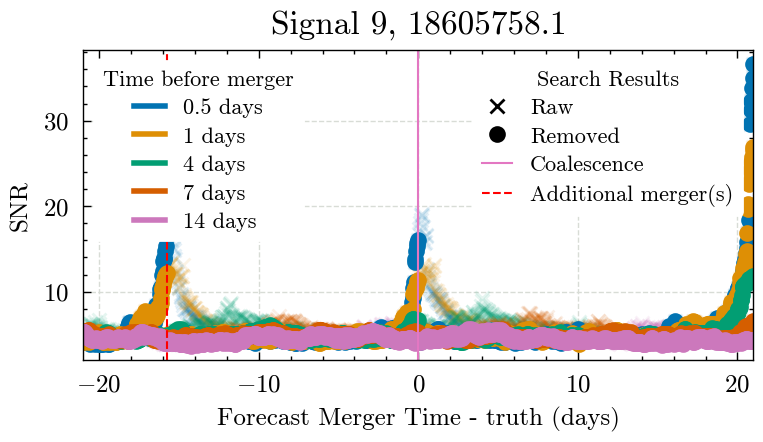

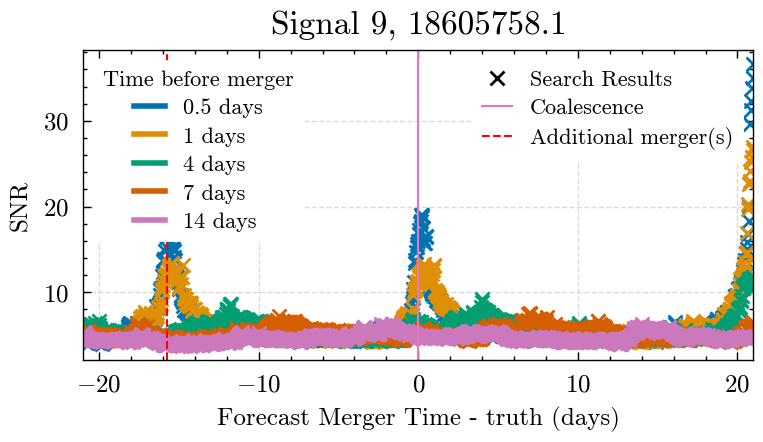

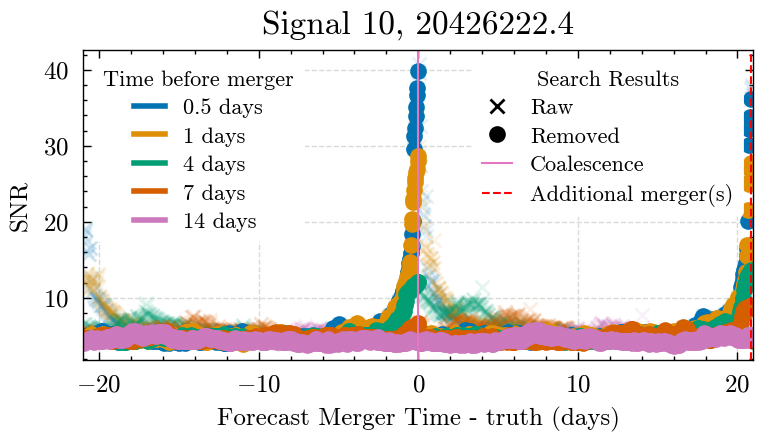

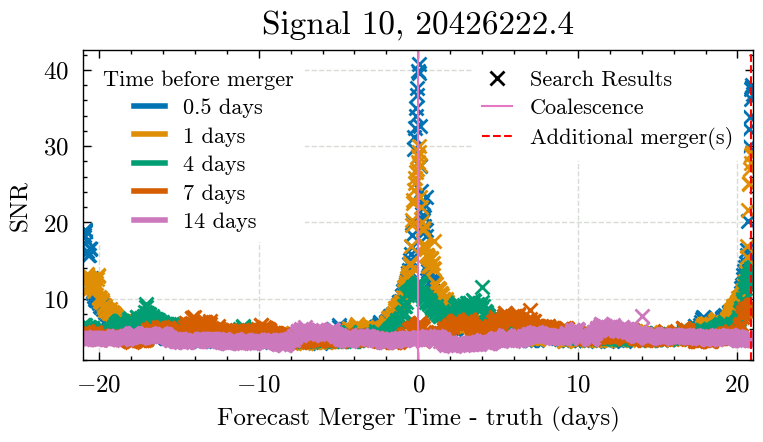

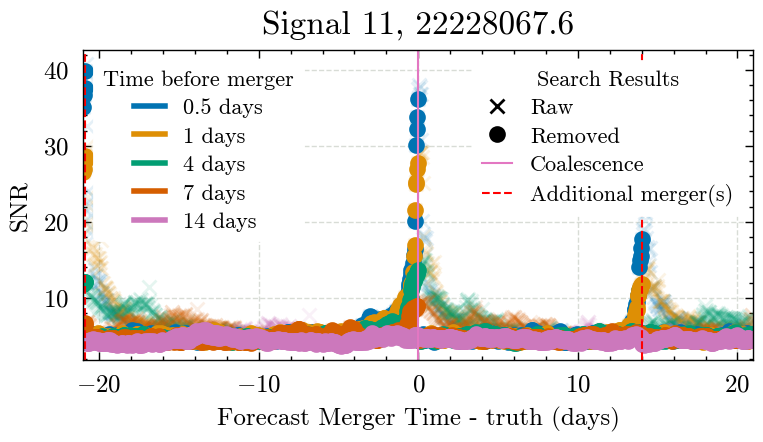

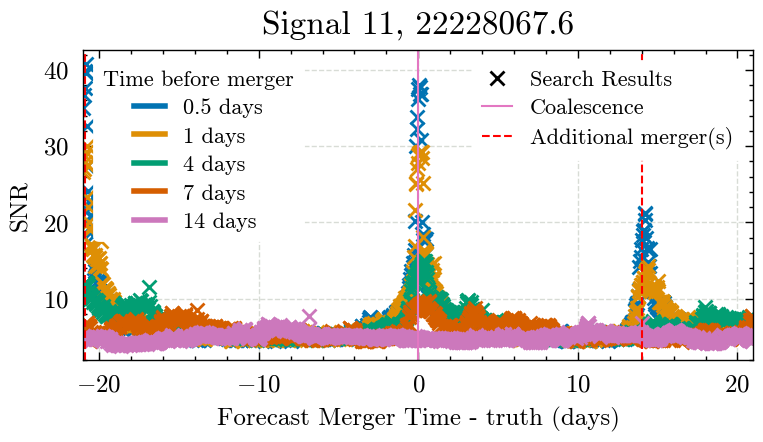

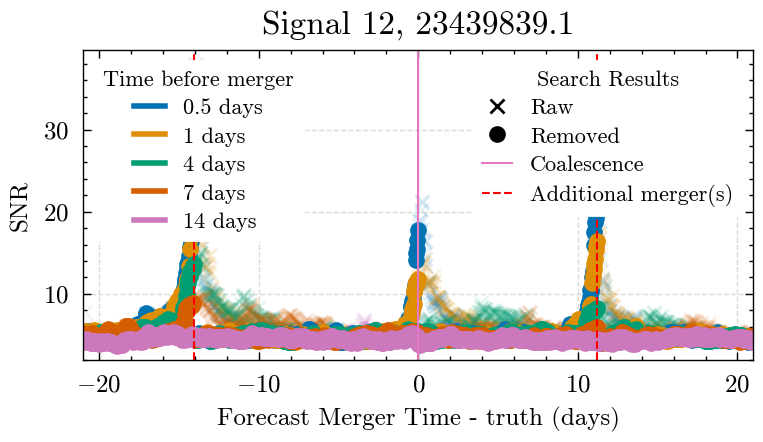

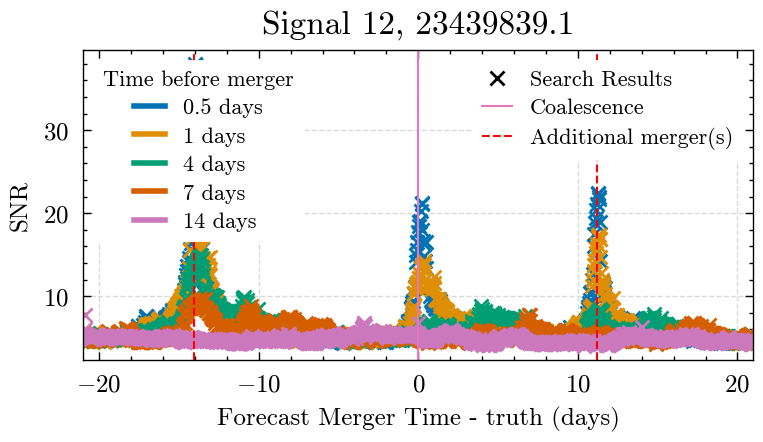

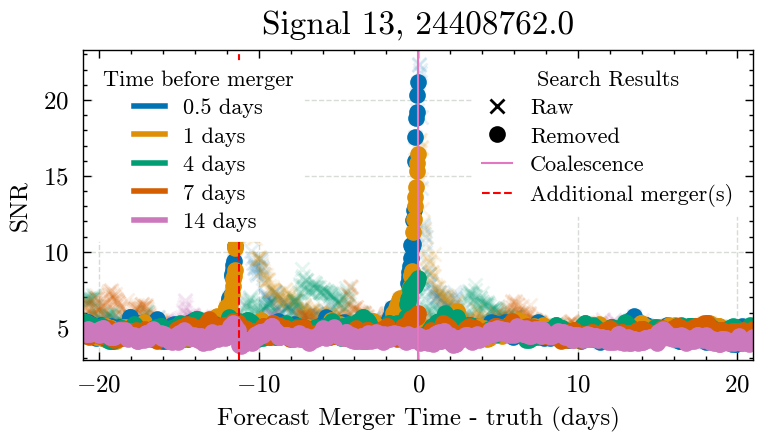

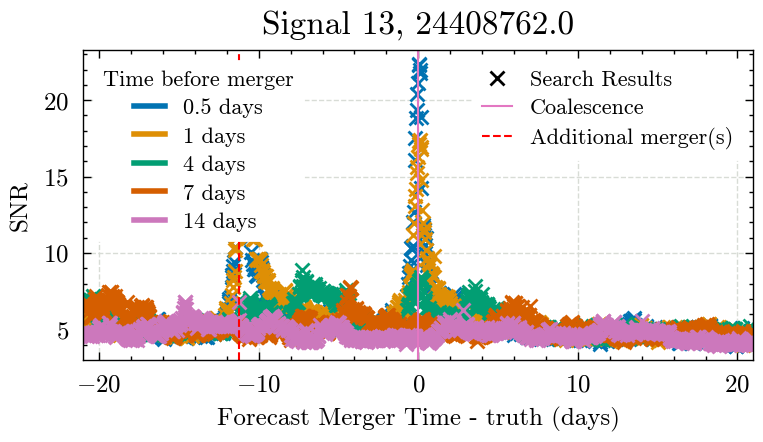

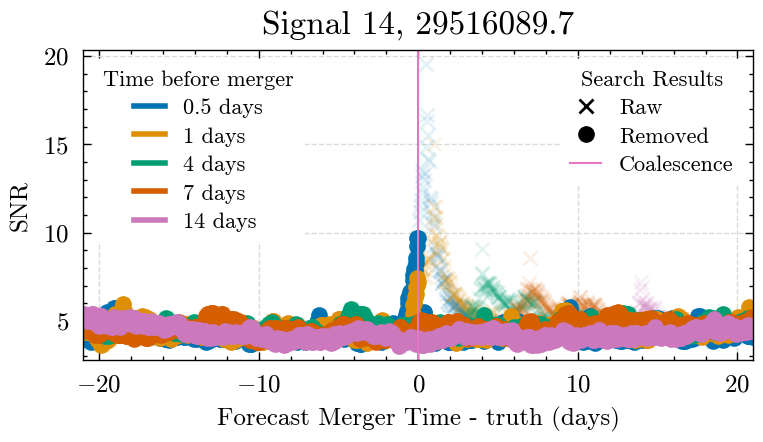

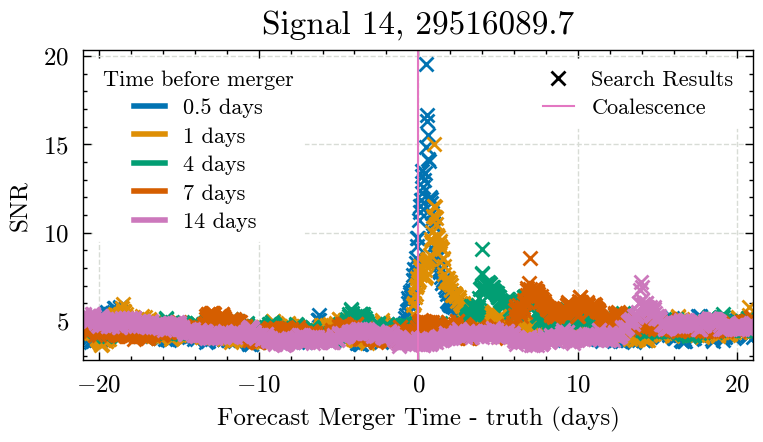

In [7]:
paper_plots_dir = '../../paper/images/zero_latency_results'

for i, truth_time_s in enumerate(truth_times_s):
    fig_remove = plot_around_time(
        truth_time_s,
        all_results_raw,
        remove_results=all_results_remove,
        signal_number=i,
        truth_times_all=truth_times_s,
        time_around=21,
    )
    fig_remove.savefig(f'{paper_plots_dir}/removed/figure_X_signal_{i}.pdf')
    fig_remove.show()

    fig_raw = plot_around_time(
        truth_time_s,
        all_results_raw,
        signal_number=i,
        truth_times_all=truth_times_s,
        time_around=21,
    )
    fig_raw.savefig(f'{paper_plots_dir}/raw/figure_X_signal_{i}.pdf')
    fig_raw.show()